# Supervised Contrastive Learning under Location-Based OOD Evaluation

## Purpose

This notebook evaluates supervised contrastive learning (SupCon) as a representation-level robustness strategy under the location-based OOD framework.

The model uses supervised contrastive objectives to organize the embedding space around damage labels before classification.

## Motivation

Representation-level robustness approaches attempt to improve generalization by encouraging the model to learn feature representations that remain useful across heterogeneous environments.

In the context of disaster damage assessment, this may reduce reliance on location-specific visual characteristics and encourage learning of more stable indicators of structural damage.

## Main Tasks

* Execute the SupCon model
* Evaluate performance on OOD partitions
* Aggregate results across random seeds
* Compute confidence intervals
* Generate confusion matrices
* Compare disaster-level performance

## Inputs

```text
OOD_train
OOD_test
OOD_hold
```

generated during OOD preprocessing.

## Outputs

The notebook generates:

* Average OOD Macro F1
* Class-specific OOD F1 scores
* Confidence intervals
* Confusion matrices
* Disaster-level comparisons
* Robustness summary statistics

These outputs are used to evaluate the effectiveness of representation-level robustness under location-based distribution shift.


## Load packages

In [2]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


## Run the model

In [ ]:
import sys
!{sys.executable} models/OOD_SupCon.py

Loading OOD data...

Using environment column for per environment analysis: disaster

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

OOD validation label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

OOD hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Train environments:
['hurricane-harvey', 'hurricane-matthew', 'mexico-earthquake', 'palu-tsunami']

OOD validation environments:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

OOD hold environments:
['hurricane-michael', 'socal-fire']

Image overlap check:
OOD_train intersection OOD_val: 

## Check confidence intervals

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import t

# ============================================================
# Configuration
# ============================================================

BASE_DIR = Path.home() / "Desktop"


RESULTS_DIR = BASE_DIR / "OOD_training_outputs" / "resnet50_supervised_contrastive_minimal_5seeds_1se"

FINAL_RESULTS_PATH = RESULTS_DIR / "final_results_by_seed_selected_1se.csv"
PER_CLASS_PATH = RESULTS_DIR / "all_seed_per_class_metrics_selected_1se.csv"
PER_ENV_PATH = RESULTS_DIR / "all_seed_per_environment_metrics_selected_1se.csv"

OUTPUT_DIR = RESULTS_DIR / "confidence_intervals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIDENCE_LEVEL = 0.95


# ============================================================
# Helper function
# ============================================================

def compute_t_confidence_interval(values, confidence_level=0.95):
    values = pd.Series(values).dropna().astype(float)
    n = len(values)

    if n < 2:
        return {
            "n": n,
            "mean": float(values.mean()) if n == 1 else np.nan,
            "std": np.nan,
            "se": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "margin": np.nan,
        }

    mean = values.mean()
    std = values.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence_level
    t_value = t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_value * se

    return {
        "n": int(n),
        "mean": float(mean),
        "std": float(std),
        "se": float(se),
        "ci_lower": float(mean - margin),
        "ci_upper": float(mean + margin),
        "margin": float(margin),
    }


def summarize_metrics(df, metric_columns, confidence_level=0.95):
    rows = []

    for metric in metric_columns:
        if metric not in df.columns:
            print(f"Skipping missing metric: {metric}")
            continue

        stats = compute_t_confidence_interval(
            df[metric],
            confidence_level=confidence_level,
        )

        rows.append({
            "metric": metric,
            **stats,
        })

    return pd.DataFrame(rows)


# ============================================================
# 1. Model-level confidence intervals
# ============================================================

final_df = pd.read_csv(FINAL_RESULTS_PATH)

model_metric_columns = [
    "ood_val_macro_f1",
    "ood_hold_macro_f1",
    "ood_val_loss",
    "ood_hold_loss",
    "ood_val_f1_no_damage",
    "ood_val_f1_minor",
    "ood_val_f1_major",
    "ood_val_f1_destroyed",
    "ood_hold_f1_no_damage",
    "ood_hold_f1_minor",
    "ood_hold_f1_major",
    "ood_hold_f1_destroyed",
]

model_ci = summarize_metrics(
    final_df,
    model_metric_columns,
    confidence_level=CONFIDENCE_LEVEL,
)

model_ci.to_csv(
    OUTPUT_DIR / "model_level_95_confidence_intervals.csv",
    index=False,
)

print("\nModel-level 95% confidence intervals:")
display(model_ci.round(4))


# ============================================================
# 2. Per-class confidence intervals
# ============================================================

if PER_CLASS_PATH.exists():
    per_class_df = pd.read_csv(PER_CLASS_PATH)

    per_class_rows = []

    for (split, class_id, class_name), group in per_class_df.groupby(
        ["split", "class_id", "class_name"]
    ):
        stats = compute_t_confidence_interval(
            group["f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_class_rows.append({
            "split": split,
            "class_id": class_id,
            "class_name": class_name,
            "metric": "f1",
            **stats,
        })

    per_class_ci = pd.DataFrame(per_class_rows)

    per_class_ci.to_csv(
        OUTPUT_DIR / "per_class_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-class 95% confidence intervals:")
    display(per_class_ci.round(4))

else:
    print(f"\nPer-class file not found: {PER_CLASS_PATH}")


# ============================================================
# 3. Per-environment confidence intervals
# ============================================================

if PER_ENV_PATH.exists():
    per_env_df = pd.read_csv(PER_ENV_PATH)

    per_env_rows = []

    for (split, environment), group in per_env_df.groupby(
        ["split", "environment"]
    ):
        stats = compute_t_confidence_interval(
            group["macro_f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_env_rows.append({
            "split": split,
            "environment": environment,
            "metric": "macro_f1",
            **stats,
        })

    per_env_ci = pd.DataFrame(per_env_rows)

    per_env_ci.to_csv(
        OUTPUT_DIR / "per_environment_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-environment 95% confidence intervals:")
    display(per_env_ci.round(4))

else:
    print(f"\nPer-environment file not found: {PER_ENV_PATH}")



print("\nSaved confidence interval outputs to:")
print(OUTPUT_DIR)


Model-level 95% confidence intervals:


,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_val_macro_f1,5,0.4428,0.0134,0.0060,0.4262,0.4595,0.0167
1,ood_hold_macro_f1,5,0.3642,0.0100,0.0045,0.3518,0.3766,0.0124
2,ood_val_loss,5,0.8298,0.0549,0.0245,0.7617,0.8980,0.0681
3,ood_hold_loss,5,0.9574,0.0444,0.0199,0.9022,1.0126,0.0552
4,ood_val_f1_no_damage,5,0.8005,0.0200,0.0090,0.7756,0.8254,0.0249
5,ood_val_f1_minor,5,0.0338,0.0034,0.0015,0.0296,0.0381,0.0043
6,ood_val_f1_major,5,0.1818,0.0189,0.0084,0.1584,0.2053,0.0234
7,ood_val_f1_destroyed,5,0.7552,0.0248,0.0111,0.7244,0.7861,0.0308
8,ood_hold_f1_no_damage,5,0.8063,0.0196,0.0088,0.7820,0.8307,0.0244
9,ood_hold_f1_minor,5,0.2716,0.0397,0.0178,0.2223,0.3209,0.0493



Per-class 95% confidence intervals:


,split,class_id,class_name,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_hold,0,no-damage,f1,5,0.8063,0.0196,0.0088,0.7820,0.8307,0.0244
1,ood_hold,1,minor-damage,f1,5,0.2716,0.0397,0.0178,0.2223,0.3209,0.0493
2,ood_hold,2,major-damage,f1,5,0.1353,0.0189,0.0084,0.1119,0.1588,0.0235
3,ood_hold,3,destroyed,f1,5,0.2434,0.0264,0.0118,0.2106,0.2763,0.0328
4,ood_validation,0,no-damage,f1,5,0.8005,0.0200,0.0090,0.7756,0.8254,0.0249
5,ood_validation,1,minor-damage,f1,5,0.0338,0.0034,0.0015,0.0296,0.0381,0.0043
6,ood_validation,2,major-damage,f1,5,0.1818,0.0189,0.0084,0.1584,0.2053,0.0234
7,ood_validation,3,destroyed,f1,5,0.7552,0.0248,0.0111,0.7244,0.7861,0.0308



Per-environment 95% confidence intervals:


,split,environment,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,ood_hold,hurricane-michael,macro_f1,5,0.3692,0.0088,0.0040,0.3582,0.3801,0.0110
1,ood_hold,socal-fire,macro_f1,5,0.2995,0.0121,0.0054,0.2845,0.3145,0.0150
2,ood_validation,guatemala-volcano,macro_f1,5,0.2821,0.0154,0.0069,0.2630,0.3011,0.0191
3,ood_validation,hurricane-florence,macro_f1,5,0.3071,0.0092,0.0041,0.2957,0.3185,0.0114
4,ood_validation,midwest-flooding,macro_f1,5,0.2681,0.0067,0.0030,0.2598,0.2765,0.0084
5,ood_validation,santa-rosa-wildfire,macro_f1,5,0.4208,0.0107,0.0048,0.4075,0.4342,0.0133



Saved confidence interval outputs to:
/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive_minimal_5seeds_1se/confidence_intervals


## Confusion matrix

Loaded rows: 267015
Seeds loaded: [42, 123, 999, 2024, 2025]
Rows per seed:
seed
42      53403
123     53403
999     53403
2024    53403
2025    53403
Name: count, dtype: int64

Pooled normalized confusion matrix:
              no-damage  minor-damage  major-damage  destroyed
no-damage         0.808         0.134         0.043      0.015
minor-damage      0.615         0.300         0.062      0.023
major-damage      0.468         0.345         0.146      0.041
destroyed         0.240         0.326         0.260      0.174


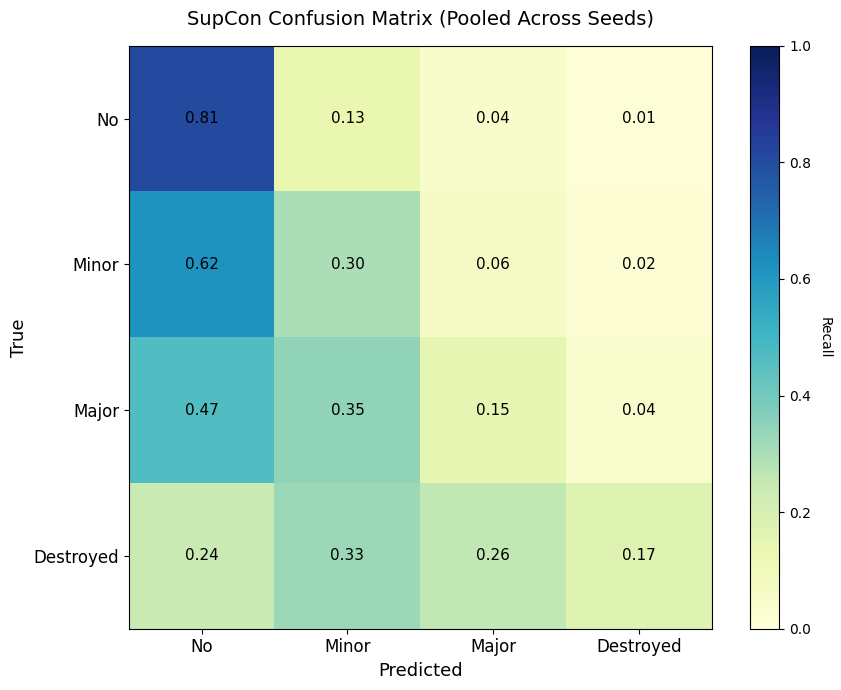

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:
    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed
    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(df))
print("Seeds loaded:", sorted(df["seed"].unique()))
print("Rows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:")
print(pd.DataFrame(cm_norm, index=labels, columns=labels).round(3))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Recall", rotation=270, labelpad=15)

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(short_labels, fontsize=12)
ax.set_yticklabels(short_labels, fontsize=12)

ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)

ax.set_title(
    "SupCon Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

plt.tight_layout()
plt.show()

## Hurricanes comparison

### Hurricane Michael

In [4]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-michael"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
)

# ============================================================
# Load all seeds
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

# ============================================================
# Filter disaster
# ============================================================

subset = df[df["disaster"] == DISASTER_NAME].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
)

print(f"\nMacro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")

print(cm)


Loaded rows: 267015

Samples in hurricane-michael: 175635

Macro F1 (hurricane-michael): 0.3711

Classification Report:

              precision    recall  f1-score   support

           0     0.7226    0.7780    0.7492    113455
           1     0.3242    0.3015    0.3125     41460
           2     0.2137    0.1403    0.1693     14595
           3     0.2720    0.2371    0.2533      6125

    accuracy                         0.5937    175635
   macro avg     0.3831    0.3642    0.3711    175635
weighted avg     0.5705    0.5937    0.5807    175635


Normalized Confusion Matrix:

[[0.77798246 0.16721167 0.0339606  0.02084527]
 [0.61459238 0.30154366 0.06133623 0.02252774]
 [0.47591641 0.34354231 0.14025351 0.04028777]
 [0.23902041 0.33812245 0.18579592 0.23706122]]


### Hurricane Florence

In [6]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-florence"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
)

class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

# ============================================================
# Load OOD validation predictions across all seeds
# Florence is in OOD_test -> validation predictions
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_val_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed

    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nAvailable disaster names:")
print(sorted(df["disaster"].astype(str).unique()))

# ============================================================
# Filter Florence
# ============================================================

subset = df[
    df["disaster"]
    .astype(str)
    .str.strip()
    .str.lower()
    == DISASTER_NAME.lower()
].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

if len(subset) == 0:
    raise ValueError(
        f"No samples found for disaster: {DISASTER_NAME}"
    )

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
    labels=[0, 1, 2, 3],
    zero_division=0,
)

print(f"\nPooled Macro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Normalized confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    labels=[0, 1, 2, 3],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")
print(cm)

# ============================================================
# Pretty DataFrame version
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion Matrix DataFrame:\n")
print(cm_df.round(3))


Loaded rows: 234165

Seeds loaded:
[42, 123, 999, 2024, 2025]

Available disaster names:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

Samples in hurricane-florence: 53640

Pooled Macro F1 (hurricane-florence): 0.3081

Classification Report:

              precision    recall  f1-score   support

   no-damage     0.8663    0.6477    0.7412     42330
minor-damage     0.0258    0.1431    0.0437      1160
major-damage     0.3346    0.5074    0.4033      9745
   destroyed     0.0336    0.0642    0.0441       405

    accuracy                         0.6069     53640
   macro avg     0.3151    0.3406    0.3081     53640
weighted avg     0.7453    0.6069    0.6595     53640


Normalized Confusion Matrix:

[[0.64772029 0.12395464 0.21674935 0.01157571]
 [0.46637931 0.14310345 0.38103448 0.00948276]
 [0.36572601 0.10148794 0.50743971 0.02534633]
 [0.30864198 0.0962963  0.5308642  0.06419753]]

Confusion Matrix DataFrame:

              no-damage  mino

## Actual vs Predicted

Available splits:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected split: 53403
Rows in prediction file: 53403

Number of available images: 1191

First available image IDs:
image_id
hurricane-michael_00000470    261
socal-fire_00000806           243
hurricane-michael_00000513    236
socal-fire_00000902           232
hurricane-michael_00000527    230
Name: count, dtype: int64

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


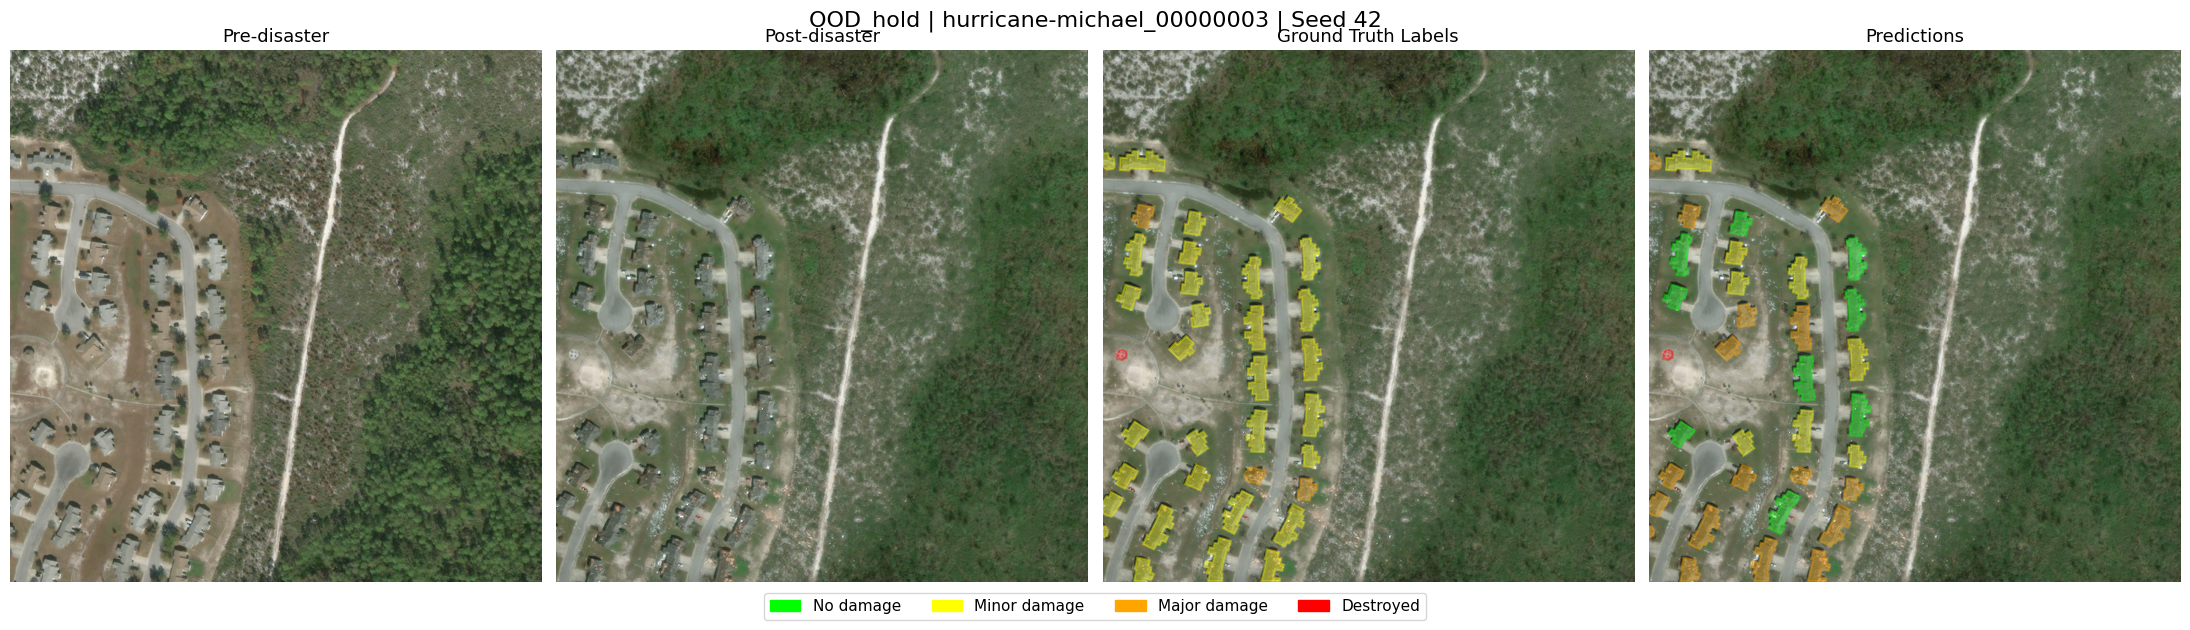

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "OOD_hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "OOD_processed"
    / "buildings_all_OOD_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "ood_hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 520

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## t-SNE

Using device: mps
Reading CSV from: /Users/paolo/Desktop/OOD_processed/buildings_all_OOD_with_crops.csv


/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/ipykernel_92961/1052257906.py:200: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))


Samples used for t-SNE:
damage_label
major-damage    1000
minor-damage    1000
no-damage       1000
destroyed       1000
Name: count, dtype: int64
Loading checkpoint from: /Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive_minimal_5seeds_1se/seed_123/checkpoints/classifier_epoch_01.pt


Extracting SupCon encoder features:   0%|          | 0/63 [00:00<?, ?it/s]

Feature matrix shape: (4000, 2048)


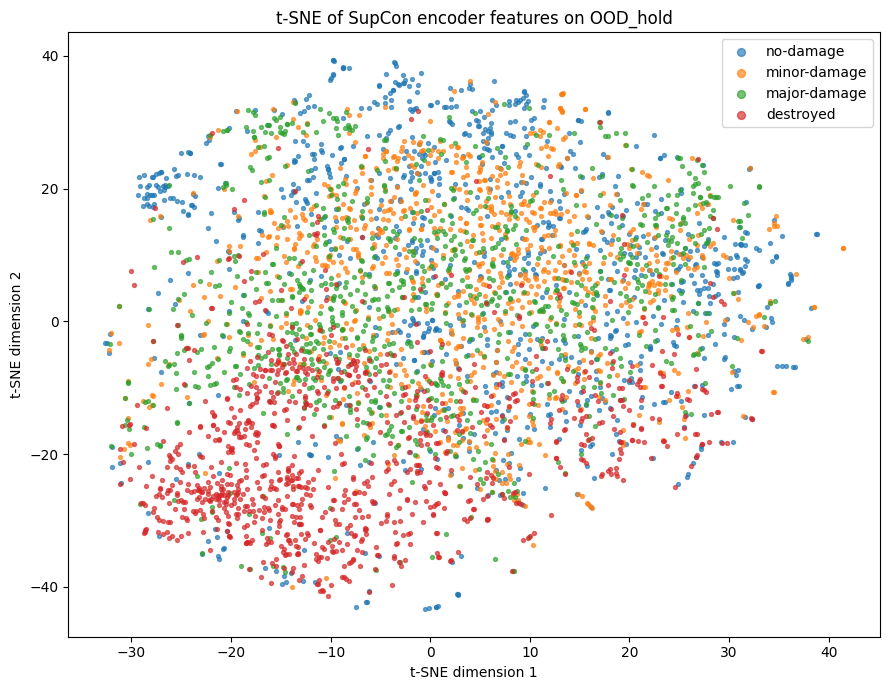

Saved CSV to: /Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive_minimal_5seeds_1se/tsne_outputs/supcon_tsne_seed_123_OOD_hold.csv
Saved figure to: /Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive_minimal_5seeds_1se/tsne_outputs/supcon_tsne_seed_123_OOD_hold.png


In [ ]:
# =========================
# t-SNE for SupCon model
# =========================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from tqdm.auto import tqdm


# -------------------------
# Config
# -------------------------

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = BASE_DIR / "OOD_processed" / "buildings_all_OOD_with_crops.csv"

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
)

TSNE_DIR = OUTPUT_DIR / "tsne_outputs"
TSNE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
SELECTED_EPOCH = 1
SPLIT_TO_PLOT = "OOD_hold"

MAX_SAMPLES_PER_CLASS = 1000
BATCH_SIZE = 64
NUM_WORKERS = 0
FEATURE_DIM = 2048

LABEL_TO_IDX = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3,
}

IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

IMAGENET_MEAN_6 = np.array(
    [0.485, 0.456, 0.406, 0.485, 0.456, 0.406],
    dtype=np.float32,
)

IMAGENET_STD_6 = np.array(
    [0.229, 0.224, 0.225, 0.229, 0.224, 0.225],
    dtype=np.float32,
)


# -------------------------
# Helpers
# -------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


# -------------------------
# Dataset
# -------------------------

class XViewBuildingDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def normalize(self, x):
        return (x - IMAGENET_MEAN_6[:, None, None]) / IMAGENET_STD_6[:, None, None]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        x = np.load(row["crop_path"])

        if x.ndim != 3:
            raise ValueError(f"Expected H,W,C crop. Got {x.shape}")

        if x.shape[2] != 6:
            raise ValueError(f"Expected 6 channels. Got {x.shape[2]}")

        x = x.astype(np.float32) / 255.0
        x = np.transpose(x, (2, 0, 1))
        x = self.normalize(x)

        y = LABEL_TO_IDX[row["damage_label"]]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


# -------------------------
# Model classes
# -------------------------

class ResNet50SixChannelEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        weights = ResNet50_Weights.IMAGENET1K_V2
        backbone = resnet50(weights=weights)

        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels=6,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight * 0.5
            new_conv.weight[:, 3:, :, :] = old_conv.weight * 0.5

        backbone.conv1 = new_conv
        backbone.fc = nn.Identity()

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


class DamageClassifierHead(nn.Module):
    def __init__(self, input_dim=2048, num_classes=4):
        super().__init__()
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, features):
        return self.classifier(features)


class FullDamageClassifier(nn.Module):
    def __init__(self, encoder, classifier_head):
        super().__init__()
        self.encoder = encoder
        self.classifier_head = classifier_head

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier_head(features)
        return logits


# -------------------------
# Main t-SNE procedure
# -------------------------

set_seed(SEED)
device = get_device()

print(f"Using device: {device}")
print(f"Reading CSV from: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df = df[df["damage_label"].isin(LABEL_TO_IDX.keys())].copy()

plot_df = df[df["split"] == SPLIT_TO_PLOT].copy().reset_index(drop=True)

plot_df = (
    plot_df
    .groupby("damage_label", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Samples used for t-SNE:")
print(plot_df["damage_label"].value_counts())

loader = DataLoader(
    XViewBuildingDataset(plot_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

model = FullDamageClassifier(
    encoder=ResNet50SixChannelEncoder(),
    classifier_head=DamageClassifierHead(input_dim=FEATURE_DIM, num_classes=4),
).to(device)

checkpoint_path = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "checkpoints"
    / f"classifier_epoch_{SELECTED_EPOCH:02d}.pt"
)

print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

features_all = []
labels_all = []

with torch.no_grad():
    for x, y in tqdm(loader, desc="Extracting SupCon encoder features"):
        x = x.to(device)

        features = model.encoder(x)

        features_all.append(features.cpu().numpy())
        labels_all.append(y.numpy())

features = np.concatenate(features_all, axis=0)
labels = np.concatenate(labels_all, axis=0)

print("Feature matrix shape:", features.shape)

features_scaled = StandardScaler().fit_transform(features)

try:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=SEED,
        max_iter=1000,
    )
except TypeError:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=SEED,
        n_iter=1000,
    )

tsne_2d = tsne.fit_transform(features_scaled)

tsne_df = pd.DataFrame({
    "tsne_1": tsne_2d[:, 0],
    "tsne_2": tsne_2d[:, 1],
    "label_id": labels,
    "label": [IDX_TO_LABEL[int(y)] for y in labels],
})

csv_path = TSNE_DIR / f"supcon_tsne_seed_{SEED}_{SPLIT_TO_PLOT}.csv"
png_path = TSNE_DIR / f"supcon_tsne_seed_{SEED}_{SPLIT_TO_PLOT}.png"

tsne_df.to_csv(csv_path, index=False)

plt.figure(figsize=(9, 7))

for label_id, label_name in IDX_TO_LABEL.items():
    subset = tsne_df[tsne_df["label_id"] == label_id]

    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        s=8,
        alpha=0.65,
        label=label_name,
    )

plt.title(f"t-SNE of SupCon encoder features on {SPLIT_TO_PLOT}")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.show()

print(f"Saved CSV to: {csv_path}")
print(f"Saved figure to: {png_path}")

### t-SNE comparison

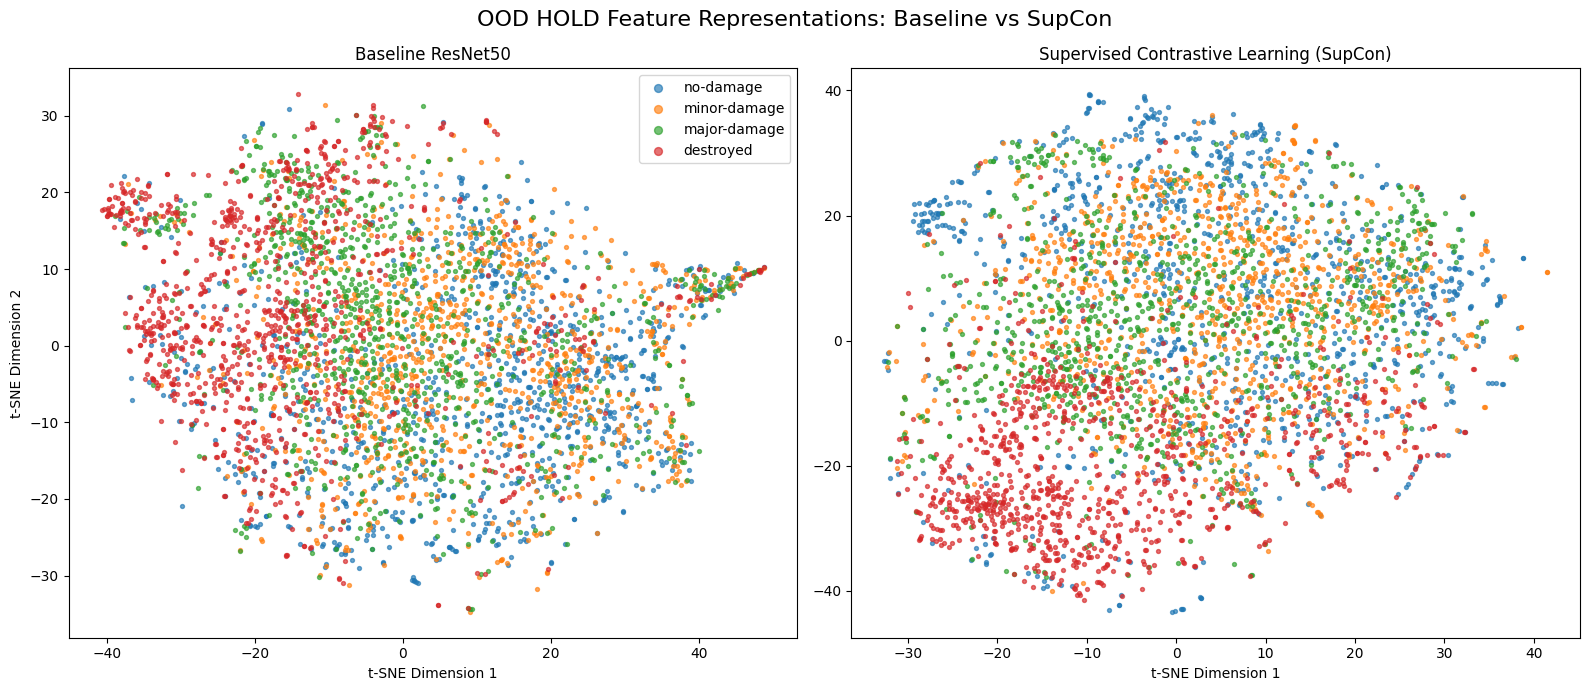

Saved figure to: /Users/paolo/Desktop/OOD_training_outputs/tsne_baseline_vs_supcon.png


In [14]:
# =========================
# Side-by-side t-SNE comparison
# Baseline vs SupCon
# =========================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.home() / "Desktop"

BASELINE_CSV = (
    BASE_DIR
    / "OOD_training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
    / "tsne_outputs"
    / "baseline_tsne_seed_123_OOD_hold.csv"
)

SUPCON_CSV = (
    BASE_DIR
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_minimal_5seeds_1se"
    / "tsne_outputs"
    / "supcon_tsne_seed_123_OOD_hold.csv"
)

baseline_df = pd.read_csv(BASELINE_CSV)
supcon_df = pd.read_csv(SUPCON_CSV)

label_order = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    sharex=False,
    sharey=False
)

# -------------------------
# Baseline
# -------------------------

ax = axes[0]

for label in label_order:
    subset = baseline_df[baseline_df["label"] == label]

    ax.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        s=8,
        alpha=0.65,
        label=label,
    )

ax.set_title("Baseline ResNet50")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(markerscale=2)

# -------------------------
# SupCon
# -------------------------

ax = axes[1]

for label in label_order:
    subset = supcon_df[supcon_df["label"] == label]

    ax.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        s=8,
        alpha=0.65,
        label=label,
    )

ax.set_title("Supervised Contrastive Learning (SupCon)")
ax.set_xlabel("t-SNE Dimension 1")

# -------------------------
# Final formatting
# -------------------------

fig.suptitle(
    "OOD HOLD Feature Representations: Baseline vs SupCon",
    fontsize=16
)

plt.tight_layout()

output_path = (
    BASE_DIR
    / "OOD_training_outputs"
    / "tsne_baseline_vs_supcon.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {output_path}")